# Train, save, reload, and compare a field model

**Learning objective.** Train a model for a linear Helmholtz-like field, organise data by whole load case, reload its parameters, and compare held-out fields using a defined model interface.

**Predict first.** Predict how splitting individual nodes from one load case could affect the test error, and which input mappings would change when replacing the MLP with a CNN, GNN or GNO.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

[Download practice notebook](../../notebooks/study/04_train_save_reload_adapter.ipynb) · [Download with worked solutions](../../notebooks/solutions/04_train_save_reload_adapter.ipynb) · [Environment setup](../../SETUP.md)

We train a small multilayer perceptron on solutions of
`ToyHelmholtzProblem`, a linear field equation with a known discrete
residual. This model problem lets us study data splits, saved model
metadata and predictions at held-out loads.

Feature contract: nodewise `[x/L, y/H, load_factor]`, all
dimensionless, in exactly that order; output: one nodewise
damage-like proposal in `[0,1]`. Training, validation and test sets
contain separate whole load cases, so each field belongs to one split.


In [1]:
from pathlib import Path
import sys

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents, Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()):
        direct = base / "teaching" / "ukacm_autumn_school_2026"
        if (direct / "notebooks" / "day2_helpers").is_dir():
            return direct
        if (base / "notebooks" / "day2_helpers").is_dir():
            return base
    raise FileNotFoundError("Could not find teaching/ukacm_autumn_school_2026.")

COURSE_ROOT = locate_course_root()
if str(COURSE_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "notebooks"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display

from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Embed a PNG even when nbclient uses a non-interactive Agg backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

print({"course_layout": "teaching/ukacm_autumn_school_2026 located", "torch": torch.__version__, "device": "cpu", "dtype": str(torch.get_default_dtype())})


{'course_layout': 'teaching/ukacm_autumn_school_2026 located', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64'}


In [2]:
from day2_helpers.course_tools import (
    FEATURE_ORDER, TinyDamageMLP, ToyHelmholtzProblem,
    load_toy_model, make_toy_checkpoint, normalise_features,
)

checkpoint_path = assets_dir() / "models" / "tiny_damage_mlp.pt"
checkpoint = make_toy_checkpoint(checkpoint_path, epochs=400, force=True)
metadata = checkpoint["metadata"]
print({"checkpoint": str(checkpoint_path.relative_to(COURSE_ROOT)), "metadata": metadata, "history": checkpoint["history"], "metrics": checkpoint["metrics"]})


{'checkpoint': 'assets/day2_forward/models/tiny_damage_mlp.pt', 'metadata': {'interface_version': 'ukacm-toy-damage-v1', 'architecture': 'TinyDamageMLP', 'width': 32, 'feature_order': ['x_over_L', 'y_over_H', 'load_factor'], 'feature_location': 'node', 'feature_units': ['dimensionless x/L', 'dimensionless y/H', 'dimensionless'], 'output': 'toy_damage_proposal at nodes; d=0 intact-like, d=1 saturated', 'dtype': 'float64', 'device': 'cpu', 'mesh_signature': [25, 13], 'normalisation_mean': [0.5, 0.5, 0.4400000000000001], 'normalisation_scale': [0.3005011345450644, 0.3118447648923806, 0.20087244715634883], 'splits': {'train': [0.12, 0.17818181818181816, 0.23636363636363636, 0.29454545454545455, 0.3527272727272727, 0.4109090909090909, 0.4690909090909091, 0.5272727272727273, 0.5854545454545454, 0.6436363636363637, 0.7018181818181818, 0.76], 'validation': [0.82, 0.88], 'test': [0.94, 1.0]}, 'data_provenance': 'course-owned synthetic fields from the discrete ToyHelmholtzProblem', 'seed': 20260

In [3]:
# Reload into a fresh model instance; compare the two predictions exactly.
problem = ToyHelmholtzProblem()
heldout_load = 1.00
heldout_features = problem.features(heldout_load)
heldout_reference = problem.reference_field(heldout_load)
mean = torch.tensor(metadata["normalisation_mean"], dtype=torch.float64)
scale = torch.tensor(metadata["normalisation_scale"], dtype=torch.float64)
original = TinyDamageMLP(width=metadata["width"]).to(dtype=torch.float64)
original.load_state_dict(checkpoint["state_dict"])
original.eval()
reloaded, reloaded_metadata = load_toy_model(checkpoint_path)
with torch.no_grad():
    prediction_before = original(normalise_features(heldout_features, mean, scale)).squeeze(1)
    prediction_after = reloaded(normalise_features(heldout_features, mean, scale)).squeeze(1)
reload_difference = float((prediction_before - prediction_after).abs().max())
heldout_rmse = float(torch.sqrt(torch.mean((prediction_after - heldout_reference) ** 2)))
print({"reload_max_abs_difference": reload_difference, "heldout_rmse": heldout_rmse, "feature_order": reloaded_metadata["feature_order"]})
assert reload_difference < 1.0e-12
assert heldout_rmse < 0.07


{'reload_max_abs_difference': 0.0, 'heldout_rmse': 0.05636315718170472, 'feature_order': ['x_over_L', 'y_over_H', 'load_factor']}


In [4]:
# A compatible RBF reference alternative shares the same nodewise features,
# but is a distinct architecture with its own resolution/data assumptions.
train_loads = metadata["splits"]["train"]
train_features, train_targets = problem.case_tensor(train_loads)
z_train = normalise_features(train_features, mean, scale)
z_test = normalise_features(heldout_features, mean, scale)
squared_distance = torch.cdist(z_test, z_train) ** 2
weights = torch.exp(-squared_distance / 0.18)
rbf_prediction = (weights @ train_targets).squeeze(1) / weights.sum(dim=1).clamp_min(1.0e-15)
rbf_rmse = float(torch.sqrt(torch.mean((rbf_prediction - heldout_reference) ** 2)))
print({"MLP_heldout_RMSE": heldout_rmse, "RBF_heldout_RMSE": rbf_rmse, "RBF_scope": "shared nodewise feature contract for the discrete Helmholtz model"})


{'MLP_heldout_RMSE': 0.05636315718170472, 'RBF_heldout_RMSE': 0.0997143167782659, 'RBF_scope': 'shared nodewise feature contract for the discrete Helmholtz model'}


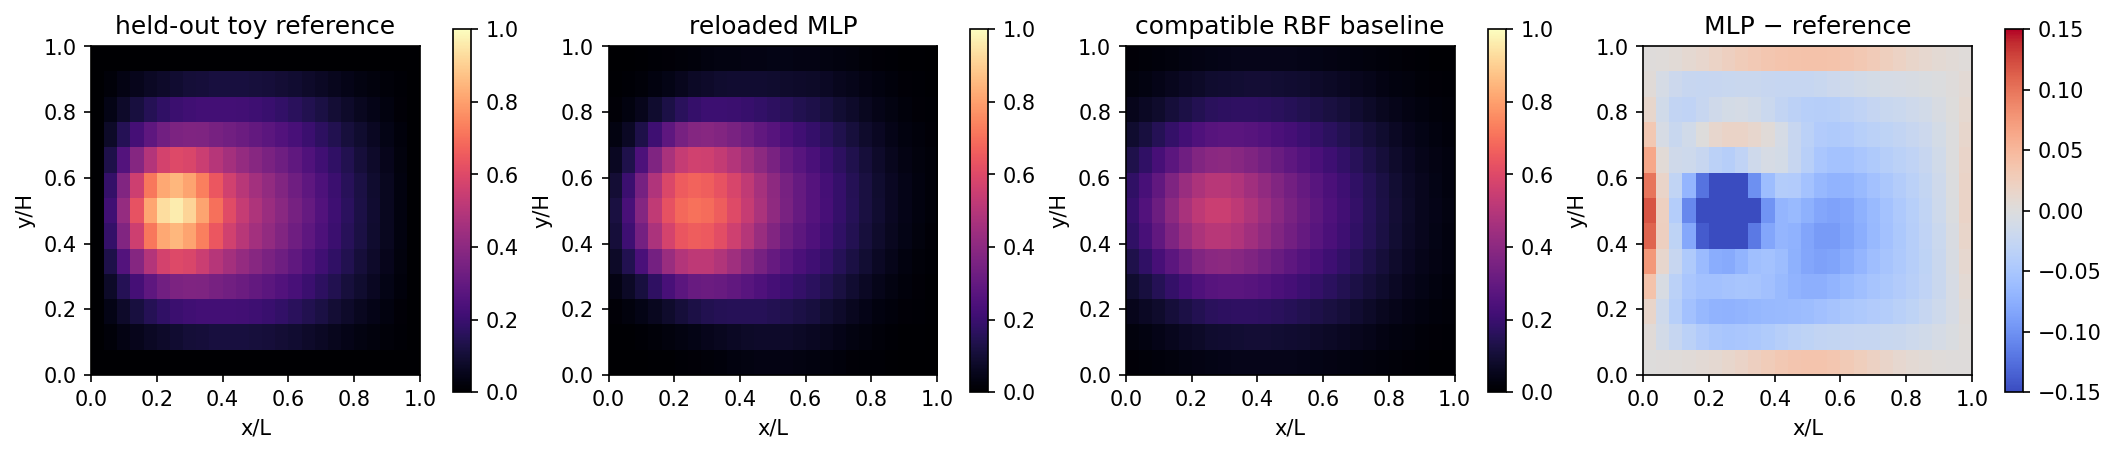

In [5]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

error = prediction_after - heldout_reference
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
for ax, values, title, cmap, limits in (
    (axes[0], heldout_reference, "held-out toy reference", "magma", (0, 1)),
    (axes[1], prediction_after, "reloaded MLP", "magma", (0, 1)),
    (axes[2], rbf_prediction, "compatible RBF baseline", "magma", (0, 1)),
    (axes[3], error, "MLP − reference", "coolwarm", (-0.15, 0.15)),
):
    image = ax.imshow(field_image(values), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78)
fig.savefig(assets_dir() / "tiny_mlp_heldout_field.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Held-out toy reference, reloaded MLP field, compatible RBF field, and MLP error.")
plt.close(fig)


The checkpoint stores the architecture width, weight `state_dict`,
feature order and units, normalisation, dtype/device, mesh
signature, data provenance, splits, seed, and training duration.
An MLP and an RBF interpolant can both consume this nodewise
representation. A CNN requires mesh-to-grid maps, while a GNN/GNO
requires connectivity or operator inputs. Define these mappings
explicitly when changing the model architecture.


## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Count examples without leaking a load case

The field grid has mesh signature $25\times13$. The checkpoint uses 12 whole load cases for training, 2 for validation, and 2 for testing. Each case supplies one nodewise feature vector $[x/L,y/H,\mathrm{load\ factor}]$ at every node.

1. Count the nodes per load case and the nodewise rows in each split.
2. Explain why all nodes from a load case are kept together in the split.
3. Is the held-out field at load factor $1.00$ part of the training split?

::::{admonition} Hint 1
:class: dropdown course-hint

Multiply the grid dimensions first. Then multiply the result by the number of cases in each split. Check the metadata: the test loads are $0.94$ and $1.00$.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

1. One field has

$$
25\times13=325
$$

nodes. Therefore the training split has $12\times325=3900$ nodewise rows, while validation and test each have $2\times325=650$ rows.

2. Nodes from one load case share the same field and load context. Splitting the nodes of one field between training and test partly measures interpolation within a seen load case. Keeping entire loads together evaluates predictions at held-out load cases.

3. The held-out field belongs to the test split. The checkpoint metadata lists test loads $0.94$ and $1.00$, so the notebook's held-out comparison at $1.00$ uses a test case. Both fields solve the same Helmholtz-like model problem at different loads.
::::

### Exercise 2: Interpret reload agreement and the MLP/RBF comparison

The output gives reload maximum absolute difference $0$, held-out MLP RMSE $0.0563631572$, and held-out RBF RMSE $0.0997143168$.

1. Compute the RMSE improvement of the MLP over the RBF on this held-out field.
2. List four checkpoint/interface facts that must be checked before inference.
3. Explain the meaning of reload difference $0$ and propose a separate generalisation check.

::::{admonition} Hint 2
:class: dropdown course-hint

Subtract the two RMSE values for the absolute gap. Read the metadata card: it records architecture, feature order, normalisation, and mesh information.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

1. The absolute held-out RMSE gap is

$$
0.0997143168-0.0563631572=0.0433511596.
$$

The MLP has the lower RMSE on this held-out field. Further load cases and repeated training runs would show how this comparison varies.

2. Examples of required facts are: the architecture identifier and width; the **state_dict** weights; exact feature order $[x/L,y/H,\mathrm{load\ factor}]$ and units; normalisation mean and scale; nodewise feature location; dtype/device; mesh signature $[25,13]$; the training-data provenance and supported scope. Choose four and explain how each affects inference.

3. A reload difference of $0$ verifies that a fresh instance reconstructed from the saved metadata and weights produced the same prediction for this tested input. To assess generalisation, compare predictions with reference fields at additional held-out loads or on another mesh. A CNN needs explicit mesh-to-grid and grid-to-mesh maps; a GNN/GNO needs graph or operator information.
::::